<a href="https://colab.research.google.com/github/sh-js98/PythorchTuturial/blob/main/Simple_NeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [36]:
# Create a model class that inherits the nn.Module
class Model (nn.Module):
  # Input layer ( 4 features of the flower) -->
  # Hidden Layer 1 (number of neurons) -->
  # H2 (n) -->
  # output (3 classes of iris flowers)
  def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    super().__init__() # instantiate our nn model
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, out_features)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)
    return x


In [37]:
# Pick a manual seed for randomization
torch.manual_seed(41)
# Create an instance of model
model = Model()

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline

In [6]:
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/refs/heads/master/iris.csv'
my_df = pd.read_csv(url)

In [7]:
# Change last colum from strings to integers
my_df['species'] = my_df['species'].replace('Setosa', 0.0)
my_df['species'] = my_df['species'].replace('Versicolor', 1.0)
my_df['species'] = my_df['species'].replace('Virginica', 2.0)
my_df



,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [8]:
# Train Test Split! Set x, y
X = my_df.drop('species', axis=1).values
y = my_df['species'].values

In [9]:
# Conveert these to numpy arrays
X = my_df.drop('species', axis=1).values
y = my_df['species'].values

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [12]:
# Convert X  features to float tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)


In [13]:
import numpy as np
import torch

# 1. Manually map the strings to numbers if they are still strings
# This handles the 'versicolor' issue we saw earlier
label_map = {'setosa': 0.0, 'versicolor': 1.0, 'virginica': 2.0}

if y_train.dtype == object:
    # Convert everything to lowercase strings first to avoid case issues,
    # then map them to numbers, then cast to float
    y_train = np.array([label_map[str(i).lower().strip()] for i in y_train])
    y_test = np.array([label_map[str(i).lower().strip()] for i in y_test])

# 2. Now that they are confirmed as numbers (floats),
# PyTorch can easily turn them into LongTensors (integers)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

print("Success! y_train and y_test are now PyTorch Tensors.")

Success! y_train and y_test are now PyTorch Tensors.


In [14]:
# Set the criterion of model to measure the error, how far off the predictions are the data
criterion = nn.CrossEntropyLoss()
# Choose Adam Optimizer, Lr = Learning rate (if error does'nt go after a bunch of iteration (epochs), lower our learning rate )
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [15]:
# Train our Model!
# Epochs? (one run through all training data in our network)
epochs = 100
losses = []
for i in range(epochs):
  # Go forward and get a prediction
  y_pred = model.forward(X_train) # Get predicted results
  # Measure the loss/error, gonna be high at first
  loss = criterion(y_pred, y_train) # predicted values vs the y_train

  #keep track our losses
  losses.append(loss.detach().numpy())

  # print every 10 epoch
  if i % 10 == 0:
    print(f'Epoch: {i} Loss: {loss}')

    # Do some back propogation: take the error rate of the forward propogation and feed it back  through the network to fine fune the weights
    optimizer.zero_grad()
  loss.backward()
  optimizer.step()




Epoch: 0 Loss: 1.125203251838684
Epoch: 10 Loss: 1.0254379510879517
Epoch: 20 Loss: 0.8960084915161133
Epoch: 30 Loss: 0.7115135192871094
Epoch: 40 Loss: 0.6809767484664917
Epoch: 50 Loss: 0.5039757490158081
Epoch: 60 Loss: 0.4309575855731964
Epoch: 70 Loss: 0.5897703170776367
Epoch: 80 Loss: 0.39321884512901306
Epoch: 90 Loss: 0.5050384998321533


Text(0.5, 0, 'Epoch')

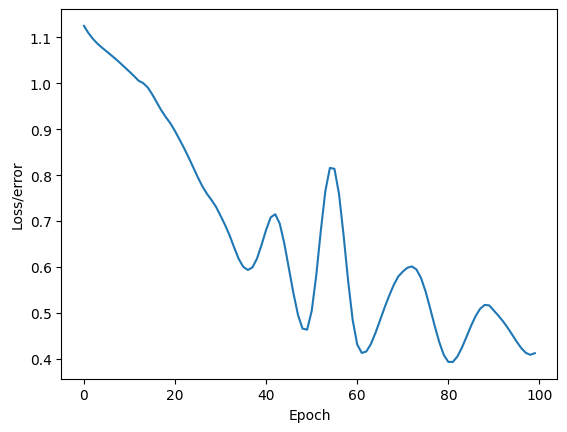

In [16]:
# Graph it out
plt.plot(range(epochs), losses)
plt.ylabel('Loss/error')
plt.xlabel('Epoch')


In [18]:
 # Evaluate Model on Test Data Set (validate model on test set)
with torch.no_grad():
    # Indent these lines:
    y_eval = model.forward(X_test)
    loss = criterion(y_eval, y_test)

# Anything back at this indentation level is outside the no_grad() block

In [19]:
loss

tensor(0.4532)

In [33]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    if y_test[i] == 0.0:
      x = "Setosa"
    elif y_test[i] == 1.0:
      x = "Versicolor"
    else:
      x = 'Virginica'
    # will tell us what type of flower class
    print(f'{i+1}.) {str(y_val)} \t {y_test[i]}')

    # correct or not
    if y_val.argmax().item() == y_test[i]:
      correct += 1

print(f'we got {correct}  correct!')

1.) tensor([-3.9782,  3.4013,  3.1231]) 	 2
2.) tensor([-4.8887,  3.9360,  3.8956]) 	 2
3.) tensor([-5.7047,  4.4169,  4.5728]) 	 2
4.) tensor([-3.5480,  3.1473,  2.7713]) 	 1
5.) tensor([-4.9217,  3.9558,  3.9195]) 	 2
6.) tensor([-3.1814,  2.9333,  2.4477]) 	 1
7.) tensor([-4.2209,  3.5443,  3.3249]) 	 2
8.) tensor([-3.5873,  3.1701,  2.8081]) 	 1
9.) tensor([-4.5764,  3.7527,  3.6294]) 	 2
10.) tensor([-5.2861,  4.1693,  4.2346]) 	 2
11.) tensor([-4.1004,  3.4724,  3.2333]) 	 2
12.) tensor([ 2.4599, -0.4886, -1.8586]) 	 0
13.) tensor([ 2.2868, -0.3768, -1.7623]) 	 0
14.) tensor([-2.2841,  2.4059,  1.6903]) 	 1
15.) tensor([ 2.0695, -0.2364, -1.6415]) 	 0
16.) tensor([-4.0038,  3.4153,  3.1557]) 	 2
17.) tensor([ 2.2212, -0.3345, -1.7259]) 	 0
18.) tensor([-4.0308,  3.4311,  3.1785]) 	 1
19.) tensor([ 2.6005, -0.5795, -1.9368]) 	 0
20.) tensor([ 2.0505, -0.2242, -1.6309]) 	 0
21.) tensor([-2.6226,  2.6046,  1.9783]) 	 1
22.) tensor([-5.2149,  4.1280,  4.1688]) 	 2
23.) tensor([ 2.090

In [40]:
new_iris = torch.tensor([3.2, 121.2, 345.5, 4.1])

In [41]:
with torch.no_grad():
  print(model(new_iris))


tensor([16.7569, -6.3417,  4.3350])


In [46]:
newer_iris = torch.tensor([5.9, 3.0, 5.1, 1.0])

In [44]:
with torch.no_grad():
  print(model(newer_iris))

tensor([ 51.7037, -23.6892,  24.2082])


In [47]:
# Save our NN  Model
torch.save(model.state_dict(), 'my_really_awesome_model.pt')


In [48]:
# Load the Saved Model
new_model =Model()
new_model.load_state_dict(torch.load('my_really_awesome_model.pt'))

<All keys matched successfully>

In [49]:
# Mke aure it loaded correctly
new_model.eval()


Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)